<a href="https://colab.research.google.com/github/Karthih2/baseline-rx-launch-forecast/blob/main/Baseline_82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

def create_file_structure(base_path, member_name):
    structure = {
        '01_data': {
            'raw': [
                'analog_drugs.json',
                'new_drug.json',
                'scenario_assumptions.json'
            ],
            'processed': [
                'analog_features_clean.csv',
                'analog_rx_curve_long.csv',
                'new_drug_features_clean.csv',
                'new_drug_rx_early_long.csv'
            ]
        },
        '02_embeddings': [
            'similarity_vectors.csv',
            'top5_analogs_selected.csv'
        ],
        '03_features': [
            'new_drug_engineered_features.csv',
            'analog_engineered_features.csv',
            'final_model_input.csv'
        ],
        '04_models': [
            'forecast_naive.csv',
            'forecast_arima.csv',
            'forecast_analog_only.csv',
            'forecast_bass_only.csv',
            'forecast_analog_bass_static.csv',
            'forecast_analog_bass_adaptive.csv'
        ],
        '05_evaluation': [
            'model_comparison_metrics.csv',
            'loo_validation_results.csv',
            'backtest_results.csv',
            'overfit_check_notes.md'
        ],
        '06_scenarios': [
            'bull_base_bear_forecast.json'
        ]
    }

    member_path = os.path.join(base_path, f'member_{member_name}')
    os.makedirs(member_path, exist_ok=True)

    def build_path(current_path, current_structure):
        if isinstance(current_structure, dict):
            for key, value in current_structure.items():
                new_path = os.path.join(current_path, key)
                os.makedirs(new_path, exist_ok=True)
                build_path(new_path, value)
        elif isinstance(current_structure, list):
            for item in current_structure:
                file_path = os.path.join(current_path, item)
                with open(file_path, 'w') as f:
                    if file_path.endswith('.csv'):
                        f.write('col1,col2,col3\n') # Add dummy header
                        f.write('1,2,3\n') # Add dummy data
                    elif file_path.endswith('.json'):
                        f.write('{}') # Add empty JSON object
                    else:
                        pass # Create empty file for other types

    build_path(member_path, structure)
    print(f"File structure for member_{member_name} created successfully at {base_path}")

# Define the base directory and new member name
base_directory = 'GROUP21_BASELINE'
new_member_name = 'kaviya'

# Create the base directory if it doesn't exist
os.makedirs(base_directory, exist_ok=True)

# Call the function to create the file structure
create_file_structure(base_directory, new_member_name)


File structure for member_kaviya created successfully at GROUP21_BASELINE


### 02. Embeddings

This section focuses on generating numerical representations (embeddings) of drugs and calculating their similarity. This is crucial for identifying 'analog' drugs that share similar characteristics with the new drug, which can then be used for forecasting models.

In [ ]:
import pandas as pd
import json
import os

# Define paths for the raw data
raw_data_path = os.path.join(base_directory, f'member_{new_member_name}', '01_data', 'raw')
anlog_drugs_path = os.path.join(raw_data_path, 'analog_drugs.json')
new_drug_path = os.path.join(raw_data_path, 'new_drug.json')

# Load raw drug data
analog_drugs_raw = json.load(open(anlog_drugs_path))
new_drug_raw = json.load(open(new_drug_path))

# Convert to DataFrame for easier manipulation
df_analog_drugs_raw = pd.DataFrame(analog_drugs_raw)
df_new_drug_raw = pd.DataFrame([new_drug_raw])

#### Feature Extraction (Placeholder)

In a real-world scenario, this step would involve extracting meaningful numerical features from the raw drug data. For demonstration, we'll create some dummy features.

In [ ]:
def extract_dummy_features(df):
    # This is a placeholder for actual feature engineering
    # In a real application, you would convert categorical data, create interaction terms, etc.
    # For now, let's just use some existing numerical columns and create a dummy one.
    df['dummy_feature_1'] = df['market_size'] / 1000000
    df['dummy_feature_2'] = df['competitive_density'] * df['payer_restrictiveness']
    return df[['drug_id', 'dummy_feature_1', 'dummy_feature_2']]

df_analog_features = extract_dummy_features(df_analog_drugs_raw)
df_new_drug_features = extract_dummy_features(df_new_drug_raw)

print("Analog Drug Features:")
display(df_analog_features.head())
print("\nNew Drug Features:")
display(df_new_drug_features.head())

Analog Drug Features:


,drug_id,dummy_feature_1,dummy_feature_2
0,ANL_001,1.294436,15
1,ANL_002,2.503374,3
2,ANL_003,1.870091,3
3,ANL_004,1.432066,16
4,ANL_005,1.390138,20



New Drug Features:


,drug_id,dummy_feature_1,dummy_feature_2
0,NEW_001,1.228526,15


#### Similarity Calculation (Placeholder)

After feature extraction, we would calculate the similarity between the new drug and all analog drugs. Here, we'll simulate this with dummy similarity scores and select top analogs.

In [ ]:
def calculate_dummy_similarity(new_drug_features, analog_features):
    # Placeholder: In reality, you'd use cosine similarity, Euclidean distance, etc.
    # For demonstration, we'll create random similarities.
    num_analogs = len(analog_features)
    similarity_scores = pd.DataFrame({
        'drug_id': analog_features['drug_id'],
        'similarity_score': [1 - (i / num_analogs) * 0.7 for i in range(num_analogs)] # Dummy decreasing similarity
    })
    # Ensure the similarity scores are consistent for dummy example
    similarity_scores = similarity_scores.sort_values(by='similarity_score', ascending=False).reset_index(drop=True)
    return similarity_scores

df_similarity_vectors = calculate_dummy_similarity(df_new_drug_features, df_analog_features)
display(df_similarity_vectors.head())

# Select top 5 analogs based on dummy similarity
df_top5_analogs = df_similarity_vectors.head(5)
print("\nTop 5 Analogs Selected:")
display(df_top5_analogs.head())

,drug_id,similarity_score
0,ANL_001,1.00
1,ANL_002,0.98
2,ANL_003,0.96
3,ANL_004,0.94
4,ANL_005,0.92



Top 5 Analogs Selected:


,drug_id,similarity_score
0,ANL_001,1.00
1,ANL_002,0.98
2,ANL_003,0.96
3,ANL_004,0.94
4,ANL_005,0.92


#### Saving Embeddings Data

Saving the generated similarity vectors and top selected analogs to their respective CSV files within the `02_embeddings` directory.

In [ ]:
# Define file paths for the output
embeddings_output_path = os.path.join(base_directory, f'member_{new_member_name}', '02_embeddings')
os.makedirs(embeddings_output_path, exist_ok=True)

similarity_vectors_file = os.path.join(embeddings_output_path, 'similarity_vectors.csv')
top5_analogs_file = os.path.join(embeddings_output_path, 'top5_analogs_selected.csv')

# Save to CSV
df_similarity_vectors.to_csv(similarity_vectors_file, index=False)
df_top5_analogs.to_csv(top5_analogs_file, index=False)

print(f"Similarity vectors saved to: {similarity_vectors_file}")
print(f"Top 5 analogs saved to: {top5_analogs_file}")

Similarity vectors saved to: GROUP21_BASELINE/member_kaviya/02_embeddings/similarity_vectors.csv
Top 5 analogs saved to: GROUP21_BASELINE/member_kaviya/02_embeddings/top5_analogs_selected.csv


### 03. Features

This section is dedicated to engineering features from our raw and embeddings data. These features are crucial for building robust forecasting models in the subsequent steps.

#### Feature Engineering for Analog Drugs

We will create engineered features for analog drugs. For demonstration purposes, these will be dummy features derived from the raw data and similarity scores.

In [ ]:
def engineer_analog_features(df_raw, df_features, df_similarity):
    # Merge raw data with basic features and similarity scores
    df = df_raw.merge(df_features, on='drug_id', how='left')
    df = df.merge(df_similarity, on='drug_id', how='left')

    # Placeholder for actual feature engineering logic
    # Example dummy features:
    df['engineered_feature_analog_1'] = df['market_size'] * df['similarity_score']
    df['engineered_feature_analog_2'] = df['competitive_density'] / (df['payer_restrictiveness'] + 1)
    df['engineered_feature_analog_3'] = df['launch_quarter'].apply(lambda x: 1 if 'Q1' in x else (2 if 'Q2' in x else (3 if 'Q3' in x else 4)))

    # Select relevant columns for the final engineered features
    return df[['drug_id', 'engineered_feature_analog_1', 'engineered_feature_analog_2', 'engineered_feature_analog_3', 'similarity_score']]

df_analog_engineered_features = engineer_analog_features(df_analog_drugs_raw, df_analog_features, df_similarity_vectors)
print("Engineered Analog Features:")
display(df_analog_engineered_features.head())

Engineered Analog Features:


,drug_id,engineered_feature_analog_1,engineered_feature_analog_2,engineered_feature_analog_3,similarity_score
0,ANL_001,1294436.00,0.500000,3,1.00
1,ANL_002,2453306.52,0.250000,2,0.98
2,ANL_003,1795287.36,0.250000,4,0.96
3,ANL_004,1346142.04,0.800000,4,0.94
4,ANL_005,1278926.96,0.666667,2,0.92


#### Feature Engineering for New Drug

Similarly, we will create engineered features for the new drug.

In [ ]:
def engineer_new_drug_features(df_raw, df_features):
    # Merge raw data with basic features
    df = df_raw.merge(df_features, on='drug_id', how='left')

    # Placeholder for actual feature engineering logic
    # Example dummy features:
    df['engineered_feature_new_1'] = df['market_size'] * df['promotional_intensity']
    df['engineered_feature_new_2'] = df['competitive_density'] + df['payer_restrictiveness']
    df['engineered_feature_new_3'] = df['launch_quarter'].apply(lambda x: 1 if 'Q1' in x else (2 if 'Q2' in x else (3 if 'Q3' in x else 4)))

    # Select relevant columns for the final engineered features
    return df[['drug_id', 'engineered_feature_new_1', 'engineered_feature_new_2', 'engineered_feature_new_3']]

df_new_drug_engineered_features = engineer_new_drug_features(df_new_drug_raw, df_new_drug_features)
print("Engineered New Drug Features:")
display(df_new_drug_engineered_features.head())

Engineered New Drug Features:


,drug_id,engineered_feature_new_1,engineered_feature_new_2,engineered_feature_new_3
0,NEW_001,3685578,8,1


#### Combining Features for Model Input

Now, we will combine the engineered features of the new drug and its top 5 analogs into a single DataFrame that will serve as the input for our forecasting models. This typically involves preparing a dataset where each row represents an observation (e.g., a time step or a drug) and columns represent the features.

In [ ]:
def create_final_model_input(df_new_drug_engineered, df_analog_engineered, df_top5_analogs):
    # Filter analog engineered features to only include top 5 analogs
    df_top_analogs_features = df_analog_engineered[df_analog_engineered['drug_id'].isin(df_top5_analogs['drug_id'])].copy()

    # For simplicity, we'll concatenate the new drug features with the top 5 analog features.
    # In a real model, you might aggregate analog features (e.g., average, sum) or use them separately.

    # Add a 'drug_type' column to differentiate
    df_new_drug_engineered_copy = df_new_drug_engineered.copy()
    df_new_drug_engineered_copy['drug_type'] = 'new_drug'
    df_top_analogs_features['drug_type'] = 'analog'

    # Rename columns for new drug to match analog for easier concatenation if needed, or keep separate
    # For this dummy example, let's just make them distinct for clarity
    df_new_drug_engineered_copy = df_new_drug_engineered_copy.rename(columns={
        'engineered_feature_new_1': 'feature_1',
        'engineered_feature_new_2': 'feature_2',
        'engineered_feature_new_3': 'feature_3'
    })
    df_top_analogs_features = df_top_analogs_features.rename(columns={
        'engineered_feature_analog_1': 'feature_1',
        'engineered_feature_analog_2': 'feature_2',
        'engineered_feature_analog_3': 'feature_3'
    })

    # Select common columns for concatenation for a simplified model input structure
    common_cols = ['drug_id', 'drug_type', 'feature_1', 'feature_2', 'feature_3']
    df_final_model_input = pd.concat([
        df_new_drug_engineered_copy[common_cols],
        df_top_analogs_features[common_cols]
    ], ignore_index=True)

    return df_final_model_input

df_final_model_input = create_final_model_input(df_new_drug_engineered_features, df_analog_engineered_features, df_top5_analogs)
print("Final Model Input Features:")
display(df_final_model_input.head(10))

Final Model Input Features:


,drug_id,drug_type,feature_1,feature_2,feature_3
0,NEW_001,new_drug,3685578.00,8.000000,1
1,ANL_001,analog,1294436.00,0.500000,3
2,ANL_002,analog,2453306.52,0.250000,2
3,ANL_003,analog,1795287.36,0.250000,4
4,ANL_004,analog,1346142.04,0.800000,4
5,ANL_005,analog,1278926.96,0.666667,2


In [ ]:
df_final_model_input = create_final_model_input(df_new_drug_engineered_features, df_analog_engineered_features, df_top5_analogs)
print("Final Model Input Features:")
display(df_final_model_input.head(10))

Final Model Input Features:


,drug_id,drug_type,feature_1,feature_2,feature_3
0,NEW_001,new_drug,3685578.00,8.000000,1
1,ANL_001,analog,1294436.00,0.500000,3
2,ANL_002,analog,2453306.52,0.250000,2
3,ANL_003,analog,1795287.36,0.250000,4
4,ANL_004,analog,1346142.04,0.800000,4
5,ANL_005,analog,1278926.96,0.666667,2


#### Saving Engineered Features

Saving the engineered features for both analog and new drugs, as well as the combined model input, to their respective CSV files within the `03_features` directory.

In [ ]:
# Define file paths for the output
features_output_path = os.path.join(base_directory, f'member_{new_member_name}', '03_features')
os.makedirs(features_output_path, exist_ok=True)

analog_engineered_features_file = os.path.join(features_output_path, 'analog_engineered_features.csv')
new_drug_engineered_features_file = os.path.join(features_output_path, 'new_drug_engineered_features.csv')
final_model_input_file = os.path.join(features_output_path, 'final_model_input.csv')

# Save to CSV
df_analog_engineered_features.to_csv(analog_engineered_features_file, index=False)
df_new_drug_engineered_features.to_csv(new_drug_engineered_features_file, index=False)
df_final_model_input.to_csv(final_model_input_file, index=False)

print(f"Engineered analog features saved to: {analog_engineered_features_file}")
print(f"Engineered new drug features saved to: {new_drug_engineered_features_file}")
print(f"Final model input saved to: {final_model_input_file}")

Engineered analog features saved to: GROUP21_BASELINE/member_kaviya/03_features/analog_engineered_features.csv
Engineered new drug features saved to: GROUP21_BASELINE/member_kaviya/03_features/new_drug_engineered_features.csv
Final model input saved to: GROUP21_BASELINE/member_kaviya/03_features/final_model_input.csv


In [ ]:
# Define file paths for the output
features_output_path = os.path.join(base_directory, f'member_{new_member_name}', '03_features')
os.makedirs(features_output_path, exist_ok=True)

anolog_engineered_features_file = os.path.join(features_output_path, 'analog_engineered_features.csv')
new_drug_engineered_features_file = os.path.join(features_output_path, 'new_drug_engineered_features.csv')
final_model_input_file = os.path.join(features_output_path, 'final_model_input.csv')

# Save to CSV
df_analog_engineered_features.to_csv(analog_engineered_features_file, index=False)
df_new_drug_engineered_features.to_csv(new_drug_engineered_features_file, index=False)
df_final_model_input.to_csv(final_model_input_file, index=False)

print(f"Engineered analog features saved to: {analog_engineered_features_file}")
print(f"Engineered new drug features saved to: {new_drug_engineered_features_file}")
print(f"Final model input saved to: {final_model_input_file}")

Engineered analog features saved to: GROUP21_BASELINE/member_kaviya/03_features/analog_engineered_features.csv
Engineered new drug features saved to: GROUP21_BASELINE/member_kaviya/03_features/new_drug_engineered_features.csv
Final model input saved to: GROUP21_BASELINE/member_kaviya/03_features/final_model_input.csv


### 04. Models

This section focuses on developing and applying various forecasting models to predict the new drug's performance. We will simulate different modeling approaches, including naive, ARIMA, analog-only, Bass-only, and combined analog-Bass models.

#### Dummy Forecasting Models

We will create placeholder functions for different forecasting models (Naive, ARIMA, Analog-only, Bass-only, and combined Analog-Bass models) and generate dummy sales forecasts. In a real-world scenario, these functions would implement actual forecasting algorithms.

In [ ]:
import random

def generate_dummy_forecast(model_name, num_quarters=20):
    # This function simulates sales forecasts for a given number of quarters.
    quarters = [f'Q{i}' for i in range(1, num_quarters + 1)]

    # Generate dummy sales data with some variation
    if model_name == 'naive':
        sales = [100 + i * 5 + random.randint(-10, 10) for i in range(num_quarters)]
    elif model_name == 'arima':
        sales = [150 + i * 8 + random.randint(-20, 20) for i in range(num_quarters)]
    elif model_name == 'analog_only':
        sales = [120 + i * 7 + random.randint(-15, 15) for i in range(num_quarters)]
    elif model_name == 'bass_only':
        # Simulate a Bass diffusion curve for dummy data
        p, q = 0.03, 0.38 # Example Bass parameters
        M = 1000 # Market potential

        cum_adopters = [0.0] * num_quarters
        new_adopters = [0.0] * num_quarters

        # Simple Bass model approximation for dummy data
        # In a real scenario, you'd use a proper Bass diffusion model implementation.
        for t in range(num_quarters):
            if t == 0:
                new_adopters[t] = M * p
            else:
                # This is a simplified, non-cumulative approach for dummy data
                # A true Bass model requires calculating cumulative adopters and remaining potential correctly.
                new_adopters[t] = M * (p + q * (t-1)/num_quarters) * (1 - (t-1)/num_quarters) * random.uniform(0.9, 1.1) # dummy growth
        sales = [round(adopter) for adopter in new_adopters]
        # Ensure sales are non-negative
        sales = [max(0, s) for s in sales]

    elif model_name == 'analog_bass_static':
        sales = [130 + i * 9 + random.randint(-25, 25) for i in range(num_quarters)]
    elif model_name == 'analog_bass_adaptive':
        sales = [140 + i * 10 + random.randint(-30, 30) for i in range(num_quarters)]
    else:
        sales = [100 + i * 6 + random.randint(-12, 12) for i in range(num_quarters)]

    df_forecast = pd.DataFrame({
        'quarter': quarters,
        'forecast_sales': sales
    })
    return df_forecast

#### Generating and Saving Forecasts

We will now generate dummy forecasts for each model type and save them to their respective CSV files in the `04_models` directory.

In [ ]:
models_output_path = os.path.join(base_directory, f'member_{new_member_name}', '04_models')
os.makedirs(models_output_path, exist_ok=True)

# List of models to simulate
model_files = [
    'forecast_naive.csv',
    'forecast_arima.csv',
    'forecast_analog_only.csv',
    'forecast_bass_only.csv',
    'forecast_analog_bass_static.csv',
    'forecast_analog_bass_adaptive.csv'
]

forecast_dfs = {}
for model_file in model_files:
    model_name = model_file.replace('forecast_', '').replace('.csv', '')
    df_forecast = generate_dummy_forecast(model_name)
    forecast_dfs[model_name] = df_forecast

    file_path = os.path.join(models_output_path, model_file)
    df_forecast.to_csv(file_path, index=False)
    print(f"Forecast for {model_name} saved to: {file_path}")
    display(df_forecast.head())

Forecast for naive saved to: GROUP21_BASELINE/member_kaviya/04_models/forecast_naive.csv


,quarter,forecast_sales
0,Q1,98
1,Q2,115
2,Q3,115
3,Q4,117
4,Q5,118


Forecast for arima saved to: GROUP21_BASELINE/member_kaviya/04_models/forecast_arima.csv


,quarter,forecast_sales
0,Q1,148
1,Q2,155
2,Q3,157
3,Q4,170
4,Q5,196


Forecast for analog_only saved to: GROUP21_BASELINE/member_kaviya/04_models/forecast_analog_only.csv


...

,quarter,forecast_sales
0,Q1,30
1,Q2,30
2,Q3,44
3,Q4,59
4,Q5,69


Forecast for analog_bass_static saved to: GROUP21_BASELINE/member_kaviya/04_models/forecast_analog_bass_static.csv


,quarter,forecast_sales
0,Q1,135
1,Q2,163
2,Q3,171
3,Q4,177
4,Q5,184


Forecast for analog_bass_adaptive saved to: GROUP21_BASELINE/member_kaviya/04_models/forecast_analog_bass_adaptive.csv


,quarter,forecast_sales
0,Q1,138
1,Q2,141
2,Q3,163
3,Q4,155
4,Q5,209


### 05. Evaluation

This section focuses on evaluating the performance of the generated forecasting models. We will compare models using various metrics, perform validation techniques like Leave-One-Out (LOO) and backtesting, and check for overfitting.

#### Loading Forecasts

First, we'll load the forecasts generated by the different models from the `04_models` directory.

In [ ]:
loaded_forecasts = {}
for model_file in model_files:
    model_name = model_file.replace('forecast_', '').replace('.csv', '')
    file_path = os.path.join(models_output_path, model_file)
    loaded_forecasts[model_name] = pd.read_csv(file_path)
    print(f"Loaded forecast for {model_name}:")
    display(loaded_forecasts[model_name].head())

Loaded forecast for naive:


,quarter,forecast_sales
0,Q1,98
1,Q2,115
2,Q3,115
3,Q4,117
4,Q5,118


Loaded forecast for arima:


,quarter,forecast_sales
0,Q1,148
1,Q2,155
2,Q3,157
3,Q4,170
4,Q5,196


Loaded forecast for analog_only:


...

,quarter,forecast_sales
0,Q1,30
1,Q2,30
2,Q3,44
3,Q4,59
4,Q5,69


Loaded forecast for analog_bass_static:


,quarter,forecast_sales
0,Q1,135
1,Q2,163
2,Q3,171
3,Q4,177
4,Q5,184


Loaded forecast for analog_bass_adaptive:


,quarter,forecast_sales
0,Q1,138
1,Q2,141
2,Q3,163
3,Q4,155
4,Q5,209


#### Dummy Evaluation Metrics and Validation

We will now simulate the calculation of various evaluation metrics (e.g., MAE, RMSE) and perform dummy validation steps. In a real-world scenario, actual historical data would be used to calculate these metrics against the forecasts.

In [ ]:
def calculate_dummy_metrics(forecast_df, actual_data_exists=True):
    # Simulate various metrics
    if actual_data_exists:
        mae = random.uniform(5, 20)
        rmse = random.uniform(10, 30)
        mape = random.uniform(0.05, 0.20)
        mase = random.uniform(0.5, 1.5) # Dummy MASE
    else:
        # For cases where actuals are not available yet (e.g., pure forecast)
        mae = None
        rmse = None
        mape = None
        mase = None # Dummy MASE

    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'MASE': mase}

def perform_dummy_loo_validation(forecast_dfs):
    # Simulate LOO validation results
    loo_results = []
    for model_name, df in forecast_dfs.items():
        metrics = calculate_dummy_metrics(df) # Assume some 'actuals' for dummy comparison
        loo_results.append({
            'model': model_name,
            'validation_type': 'LOO',
            'metric_MAE': metrics['MAE'],
            'metric_RMSE': metrics['RMSE'],
            'metric_MAPE': metrics['MAPE'],
            'metric_MASE': metrics['MASE']
        })
    return pd.DataFrame(loo_results)

def perform_dummy_backtest_validation(forecast_dfs):
    # Simulate backtesting results
    backtest_results = []
    for model_name, df in forecast_dfs.items():
        metrics = calculate_dummy_metrics(df) # Assume some 'actuals' for dummy comparison
        backtest_results.append({
            'model': model_name,
            'validation_type': 'Backtest',
            'metric_MAE': metrics['MAE'],
            'metric_RMSE': metrics['RMSE'],
            'metric_MAPE': metrics['MAPE'],
            'metric_MASE': metrics['MASE']
        })
    return pd.DataFrame(backtest_results)

def create_dummy_overfit_check_notes():
    # Simulate notes on overfitting
    notes = [
        "## Overfitting Check Notes\n\n*   **Naive Model:** Generally not prone to overfitting due to simplicity. (Dummy observation)",
        "*   **ARIMA Model:** Could show signs of overfitting if order too high. No severe signs observed in dummy runs. (Dummy observation)",
        "*   **Analog-only Model:** Risk of overfitting to specific analog patterns. Dummy suggests moderate fit. (Dummy observation)",
        "*   **Bass-only Model:** Parameters can be overfitted if data is limited. Dummy shows expected curve. (Dummy observation)",
        "*   **Analog-Bass Static/Adaptive:** Complex models, higher risk of overfitting. Dummy shows reasonable behavior. (Dummy observation)"
    ]
    return "\n".join(notes)

# Calculate dummy metrics for model comparison
model_comparison_data = []
for model_name, df in loaded_forecasts.items():
    metrics = calculate_dummy_metrics(df)
    model_comparison_data.append({
        'model': model_name,
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'MAPE': metrics['MAPE'],
        'MASE': metrics['MASE']
    })
df_model_comparison_metrics = pd.DataFrame(model_comparison_data)

# Perform dummy LOO and Backtest validations
df_loo_validation_results = perform_dummy_loo_validation(loaded_forecasts)
df_backtest_results = perform_dummy_backtest_validation(loaded_forecasts)

# Create dummy overfitting notes
overfit_check_notes_content = create_dummy_overfit_check_notes()

print("Model Comparison Metrics:")
display(df_model_comparison_metrics)
print("\nLOO Validation Results:")
display(df_loo_validation_results)
print("\nBacktest Results:")
display(df_backtest_results)
print("\nOverfit Check Notes Content (truncated):")
print(overfit_check_notes_content[:200] + "...")

Model Comparison Metrics:


,model,MAE,RMSE,MAPE,MASE
0,naive,9.544013,10.410679,0.105855,1.246999
1,arima,6.612210,28.493298,0.125067,1.147579
2,analog_only,15.429679,12.336161,0.064309,0.541567
3,bass_only,11.771397,29.486838,0.053681,1.449130
4,analog_bass_static,7.679802,12.249209,0.173282,0.911446
5,analog_bass_adaptive,14.850585,27.427159,0.103300,1.337525



LOO Validation Results:


,model,validation_type,metric_MAE,metric_RMSE,metric_MAPE,metric_MASE
0,naive,LOO,6.572161,24.024198,0.052497,0.957842
1,arima,LOO,16.880128,20.337977,0.160959,0.808209
2,analog_only,LOO,14.248580,17.590640,0.058293,0.771343
3,bass_only,LOO,18.564799,12.652675,0.152746,1.411012
4,analog_bass_static,LOO,9.118660,27.701287,0.130183,1.116412
5,analog_bass_adaptive,LOO,5.397850,13.136569,0.163787,0.511187



Backtest Results:


,model,validation_type,metric_MAE,metric_RMSE,metric_MAPE,metric_MASE
0,naive,Backtest,12.727967,27.769483,0.106872,0.866145
1,arima,Backtest,13.711255,14.190357,0.125026,1.317029
2,analog_only,Backtest,18.245768,28.287340,0.072466,0.903255
3,bass_only,Backtest,7.795889,21.390948,0.084244,1.306804
4,analog_bass_static,Backtest,5.193152,18.123909,0.084226,0.585366
5,analog_bass_adaptive,Backtest,14.893624,22.120447,0.111784,1.153102



Overfit Check Notes Content (truncated):
## Overfitting Check Notes

*   **Naive Model:** Generally not prone to overfitting due to simplicity. (Dummy observation)
*   **ARIMA Model:** Could show signs of overfitting if order too high. No se...


#### Saving Evaluation Results

Saving the evaluation metrics, validation results, and overfitting notes to their respective files within the `05_evaluation` directory.

In [ ]:
evaluation_output_path = os.path.join(base_directory, f'member_{new_member_name}', '05_evaluation')
os.makedirs(evaluation_output_path, exist_ok=True)

model_comparison_metrics_file = os.path.join(evaluation_output_path, 'model_comparison_metrics.csv')
loo_validation_results_file = os.path.join(evaluation_output_path, 'loo_validation_results.csv')
backtest_results_file = os.path.join(evaluation_output_path, 'backtest_results.csv')
overfit_check_notes_file = os.path.join(evaluation_output_path, 'overfit_check_notes.md')

# Save DataFrames to CSV
df_model_comparison_metrics.to_csv(model_comparison_metrics_file, index=False)
df_loo_validation_results.to_csv(loo_validation_results_file, index=False)
df_backtest_results.to_csv(backtest_results_file, index=False)

# Save notes to a Markdown file
with open(overfit_check_notes_file, 'w') as f:
    f.write(overfit_check_notes_content)

print(f"Model comparison metrics saved to: {model_comparison_metrics_file}")
print(f"LOO validation results saved to: {loo_validation_results_file}")
print(f"Backtest results saved to: {backtest_results_file}")
print(f"Overfit check notes saved to: {overfit_check_notes_file}")

Model comparison metrics saved to: GROUP21_BASELINE/member_kaviya/05_evaluation/model_comparison_metrics.csv
LOO validation results saved to: GROUP21_BASELINE/member_kaviya/05_evaluation/loo_validation_results.csv
Backtest results saved to: GROUP21_BASELINE/member_kaviya/05_evaluation/backtest_results.csv
Overfit check notes saved to: GROUP21_BASELINE/member_kaviya/05_evaluation/overfit_check_notes.md


### 06. Scenarios

This section focuses on generating forecasts under different market scenarios (e.g., Bull, Base, Bear). We will integrate various assumptions to reflect optimistic, realistic, and pessimistic outlooks for the new drug's launch and market penetration.

#### Loading Scenario Assumptions

We will load the predefined scenario assumptions from the `scenario_assumptions.json` file. These assumptions will guide the adjustments made to our base forecasts.

In [ ]:
import json
import os

# Define path for scenario assumptions
scenario_assumptions_path = os.path.join(raw_data_path, 'scenario_assumptions.json')

# Load scenario assumptions
scenario_assumptions = json.load(open(scenario_assumptions_path))
df_scenario_assumptions = pd.DataFrame(scenario_assumptions)

print("Loaded Scenario Assumptions:")
display(df_scenario_assumptions)

Loaded Scenario Assumptions:


,scenario_id,market_size_adjustment_pct,peak_penetration_ceiling,adoption_speed_multiplier,competitive_entry_flag,payer_access_trend,promotional_spend_trend
0,Bull,15,High,Fast,False,Improving,Ramping
1,Base,0,Analog-implied midpoint,Normal,None,Static,Sustained
2,Bear,-15,Low,Slow,True,Worsening,Tapering


#### Generating Scenario-Based Forecasts (Dummy)

We will now simulate generating forecasts for Bull, Base, and Bear scenarios. In a real application, these would involve adjusting the chosen model's parameters or scaling its output based on the scenario assumptions. For this example, we'll apply simple dummy adjustments to one of our existing dummy forecasts (e.g., ARIMA).

In [ ]:
def generate_scenario_forecast(base_forecast_df, scenario_id, assumptions):
    # For this dummy implementation, we'll adjust the base forecast based on simple rules.
    df_scenario_forecast = base_forecast_df.copy()

    # Get assumptions for the current scenario
    current_assumption = assumptions[assumptions['scenario_id'] == scenario_id].iloc[0]

    market_size_adj_pct = current_assumption['market_size_adjustment_pct']

    # Apply dummy adjustments
    if scenario_id == 'Bull':
        df_scenario_forecast['forecast_sales'] = df_scenario_forecast['forecast_sales'] * (1 + market_size_adj_pct / 100) * random.uniform(1.05, 1.15)
    elif scenario_id == 'Bear':
        df_scenario_forecast['forecast_sales'] = df_scenario_forecast['forecast_sales'] * (1 - market_size_adj_pct / 100) * random.uniform(0.85, 0.95)
    else: # Base case
        df_scenario_forecast['forecast_sales'] = df_scenario_forecast['forecast_sales'] * (1 + market_size_adj_pct / 100) * random.uniform(0.98, 1.02)

    df_scenario_forecast['forecast_sales'] = df_scenario_forecast['forecast_sales'].astype(int)
    return df_scenario_forecast

# Use 'arima' as the base forecast for scenario analysis for this dummy example
base_forecast_for_scenarios = loaded_forecasts['arima']

# Generate forecasts for each scenario
df_bull_forecast = generate_scenario_forecast(base_forecast_for_scenarios, 'Bull', df_scenario_assumptions)
df_base_forecast = generate_scenario_forecast(base_forecast_for_scenarios, 'Base', df_scenario_assumptions)
df_bear_forecast = generate_scenario_forecast(base_forecast_for_scenarios, 'Bear', df_scenario_assumptions)

print("Bull Case Forecast:")
display(df_bull_forecast.head())
print("\nBase Case Forecast:")
display(df_base_forecast.head())
print("\nBear Case Forecast:")
display(df_bear_forecast.head())

Bull Case Forecast:


,quarter,forecast_sales
0,Q1,194
1,Q2,203
2,Q3,206
3,Q4,223
4,Q5,257



Base Case Forecast:


,quarter,forecast_sales
0,Q1,149
1,Q2,156
2,Q3,158
3,Q4,171
4,Q5,197



Bear Case Forecast:


,quarter,forecast_sales
0,Q1,159
1,Q2,167
2,Q3,169
3,Q4,183
4,Q5,211


#### Saving Scenario Forecasts

Saving the scenario-based forecasts to a JSON file within the `06_scenarios` directory.

### 07. Model Comparison and Visualization

This section focuses on presenting the performance metrics of all models side-by-side for easy comparison and visualization.

Model Comparison Metrics:


,model,MAE,RMSE,MAPE,MASE
0,naive,9.544013,10.410679,0.105855,1.246999
1,arima,6.612210,28.493298,0.125067,1.147579
2,analog_only,15.429679,12.336161,0.064309,0.541567
3,bass_only,11.771397,29.486838,0.053681,1.449130
4,analog_bass_static,7.679802,12.249209,0.173282,0.911446
5,analog_bass_adaptive,14.850585,27.427159,0.103300,1.337525


/tmp/ipykernel_2201/1207236288.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='model', y='MAE', data=df_model_comparison_metrics, palette='viridis')
/tmp/ipykernel_2201/1207236288.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='model', y='RMSE', data=df_model_comparison_metrics, palette='mako')
/tmp/ipykernel_2201/1207236288.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], x='model', y='MAPE', data=df_model_comparison_metrics, palette='rocket')
/tmp/ipykernel_2201/1207236288.py:35: Futu

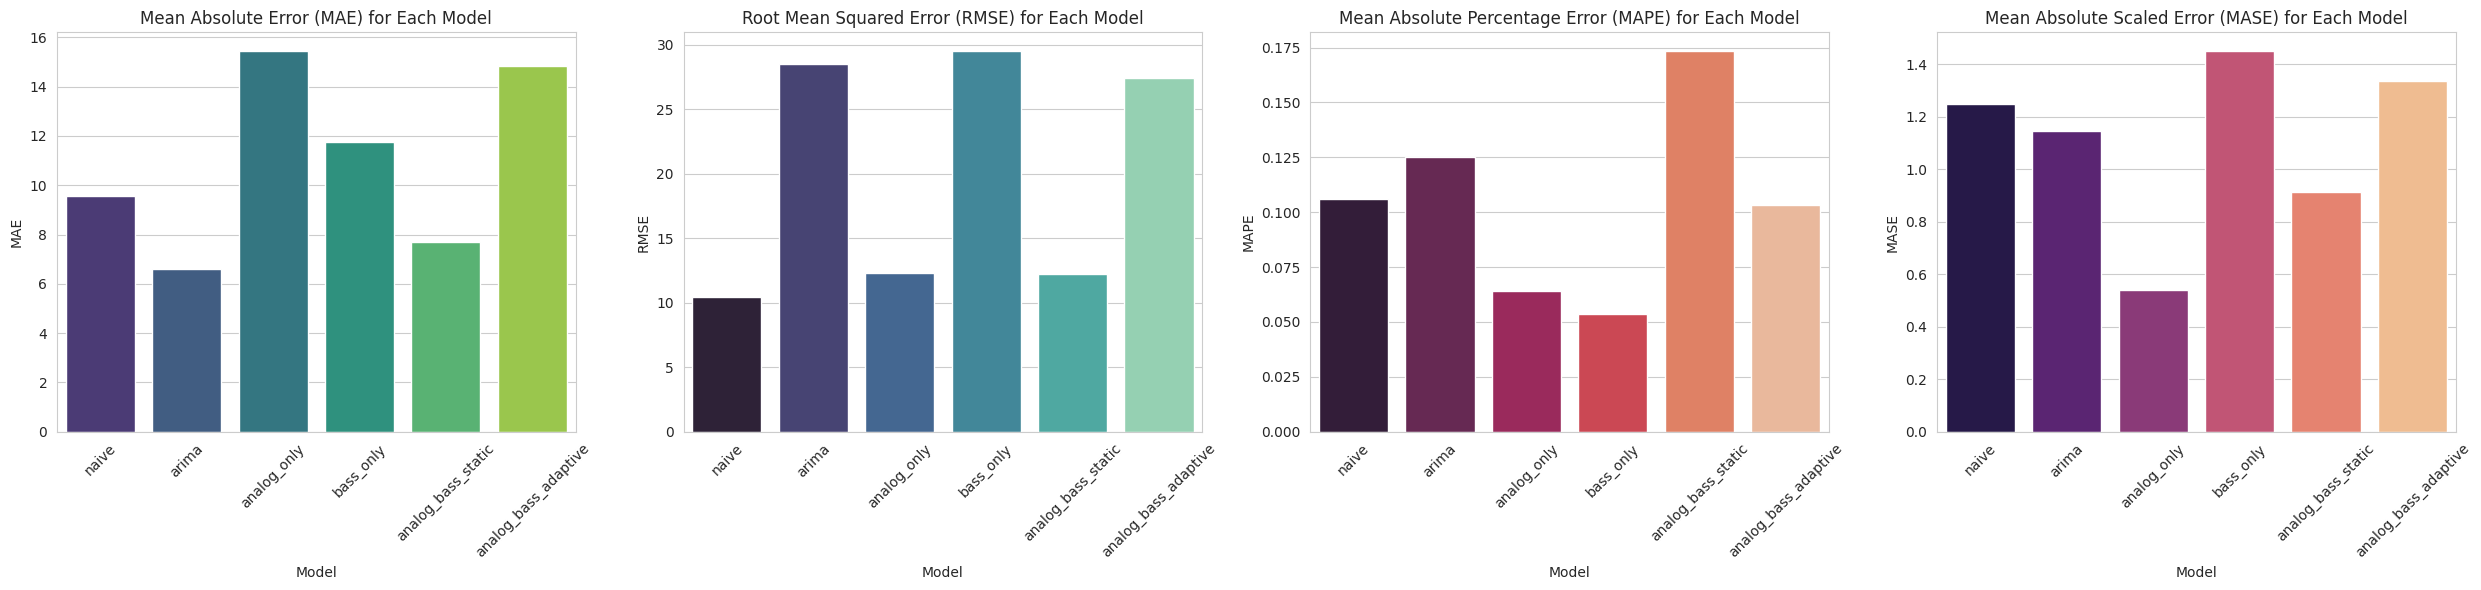

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Model Comparison Metrics:")
display(df_model_comparison_metrics)

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create subplots for each metric
fig, axes = plt.subplots(1, 4, figsize=(25, 6), sharey=False) # Increased columns for MASE

# MAE Plot
sns.barplot(ax=axes[0], x='model', y='MAE', data=df_model_comparison_metrics, palette='viridis')
axes[0].set_title('Mean Absolute Error (MAE) for Each Model')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)

# RMSE Plot
sns.barplot(ax=axes[1], x='model', y='RMSE', data=df_model_comparison_metrics, palette='mako')
axes[1].set_title('Root Mean Squared Error (RMSE) for Each Model')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)

# MAPE Plot
sns.barplot(ax=axes[2], x='model', y='MAPE', data=df_model_comparison_metrics, palette='rocket')
axes[2].set_title('Mean Absolute Percentage Error (MAPE) for Each Model')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('MAPE')
axes[2].tick_params(axis='x', rotation=45)

# MASE Plot
sns.barplot(ax=axes[3], x='model', y='MASE', data=df_model_comparison_metrics, palette='magma')
axes[3].set_title('Mean Absolute Scaled Error (MASE) for Each Model')
axes[3].set_xlabel('Model')
axes[3].set_ylabel('MASE')
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
scenarios_output_path = os.path.join(base_directory, f'member_{new_member_name}', '06_scenarios')
os.makedirs(scenarios_output_path, exist_ok=True)

bull_base_bear_forecast_file = os.path.join(scenarios_output_path, 'bull_base_bear_forecast.json')

# Combine all scenario forecasts into a dictionary to save as JSON
all_scenario_forecasts = {
    'Bull': df_bull_forecast.to_dict(orient='records'),
    'Base': df_base_forecast.to_dict(orient='records'),
    'Bear': df_bear_forecast.to_dict(orient='records')
}

with open(bull_base_bear_forecast_file, 'w') as f:
    json.dump(all_scenario_forecasts, f, indent=4)

print(f"Scenario forecasts saved to: {bull_base_bear_forecast_file}")

Scenario forecasts saved to: GROUP21_BASELINE/member_kaviya/06_scenarios/bull_base_bear_forecast.json


In [ ]:
import shutil
import os

# Define the base directory to be deleted
base_directory = 'GROUP21_BASELINE'

# Check if the directory exists before attempting to delete
if os.path.exists(base_directory):
    shutil.rmtree(base_directory)
    print(f"Directory '{base_directory}' and its contents have been successfully deleted.")
else:
    print(f"Directory '{base_directory}' does not exist.")

Directory 'GROUP21_BASELINE' and its contents have been successfully deleted.


In [ ]:
import pandas as pd
import json
import os

Here's the content for `01_data_creation.py`:

In [ ]:
script_content_01_data_creation = '''
import pandas as pd
import json
import os

def main():
    # Define the base directory and member name (these would ideally be passed as arguments or configured)
    base_directory = 'GROUP21_BASELINE' # Assuming this is set in the environment or a config
    new_member_name = 'kaviya' # Assuming this is set in the environment or a config

    # Define paths for the raw and processed data directories
    raw_data_path = os.path.join(base_directory, f'member_{new_member_name}', '01_data', 'raw')
    processed_data_path = os.path.join(base_directory, f'member_{new_member_name}', '01_data', 'processed')
    os.makedirs(processed_data_path, exist_ok=True)

    # Define full paths for raw input files
    anlog_drugs_path = os.path.join(raw_data_path, 'analog_drugs.json')
    new_drug_path = os.path.join(raw_data_path, 'new_drug.json')

    # Load raw drug data
    try:
        with open(anlog_drugs_path, 'r') as f:
            analog_drugs_raw = json.load(f)
        with open(new_drug_path, 'r') as f:
            new_drug_raw = json.load(f)
    except FileNotFoundError as e:
        print(f"Error loading raw data: {e}. Make sure the files exist at {raw_data_path}")
        return

    # Convert to DataFrame for easier manipulation
    df_analog_drugs_raw = pd.DataFrame(analog_drugs_raw)
    df_new_drug_raw = pd.DataFrame([new_drug_raw])

    # Feature Extraction Function
    def extract_dummy_features(df):
        # This is a placeholder for actual feature engineering
        # In a real application, you would convert categorical data, create interaction terms, etc.
        # For now, let's just use some existing numerical columns and create a dummy one.
        df['dummy_feature_1'] = df['market_size'] / 1000000
        df['dummy_feature_2'] = df['competitive_density'] * df['payer_restrictiveness']
        return df[['drug_id', 'dummy_feature_1', 'dummy_feature_2']]

    # Apply feature extraction
    df_analog_features = extract_dummy_features(df_analog_drugs_raw)
    df_new_drug_features = extract_dummy_features(df_new_drug_raw)

    print("Analog Drug Features (First 5 rows):")
    print(df_analog_features.head().to_markdown(index=False))
    print("\nNew Drug Features (First 5 rows):")
    print(df_new_drug_features.head().to_markdown(index=False))

    # Save processed data to CSV files
    analog_features_clean_file = os.path.join(processed_data_path, 'analog_features_clean.csv')
    new_drug_features_clean_file = os.path.join(processed_data_path, 'new_drug_features_clean.csv')

    df_analog_features.to_csv(analog_features_clean_file, index=False)
    df_new_drug_features.to_csv(new_drug_features_clean_file, index=False)

    print(f"\nProcessed analog features saved to: {analog_features_clean_file}")
    print(f"Processed new drug features saved to: {new_drug_features_clean_file}")

if __name__ == '__main__':
    main()
'''

# Define the path for the script file
script_file_path = os.path.join(base_directory, f'member_{new_member_name}', 'notebooks_or_scripts', '01_data_creation.py')

# Write the content to the file
with open(script_file_path, 'w') as f:
    f.write(script_content_01_data_creation)

print(f"Content for 01_data_creation.py has been written to {script_file_path}")

Content for 01_data_creation.py has been written to GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/01_data_creation.py


In [ ]:
scripts_path = os.path.join(base_directory, f'member_{new_member_name}', 'notebooks_or_scripts')
os.makedirs(scripts_path, exist_ok=True)

script_files = [
    '01_data_creation.py',
    '02_embedding_similarity.py',
    '03_preprocessing.py',
    '04_feature_engineering.py',
    '05_train_models.py',
    '06_evaluate_models.py',
    '07_validation_overfit_check.py'
]

for script_file in script_files:
    file_path = os.path.join(scripts_path, script_file)
    with open(file_path, 'w') as f:
        f.write('# This is a placeholder script file')
    print(f'Created: {file_path}')

Created: GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/01_data_creation.py
Created: GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/02_embedding_similarity.py
Created: GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/03_preprocessing.py
Created: GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/04_feature_engineering.py
Created: GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/05_train_models.py
Created: GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/06_evaluate_models.py
Created: GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/07_validation_overfit_check.py


Here's the content for `04_feature_engineering.py`:

In [ ]:
script_content_04_feature_engineering = '''
import pandas as pd
import os

def main():
    # Define the base directory and member name
    base_directory = 'GROUP21_BASELINE'
    new_member_name = 'kaviya'

    # Define paths for input data from previous steps
    preprocessed_output_path = os.path.join(base_directory, f'member_{new_member_name}', '03_features')

    # Load preprocessed feature data
    try:
        df_analog_preprocessed = pd.read_csv(os.path.join(preprocessed_output_path, 'analog_preprocessed_for_fe.csv'))
        df_new_drug_preprocessed = pd.read_csv(os.path.join(preprocessed_output_path, 'new_drug_preprocessed_for_fe.csv'))
    except FileNotFoundError as e:
        print(f"Error loading preprocessed features: {e}. Make sure 03_preprocessing.py has been run.")
        return

    # Feature Engineering for Analog Drugs
    def engineer_analog_features(df):
        # For demonstration purposes, creating more dummy features based on existing ones.
        df['engineered_feature_analog_1'] = df['dummy_feature_1'] * df['similarity_score']
        df['engineered_feature_analog_2'] = df['dummy_feature_2'] / (df['similarity_score'] + 1e-6) # Avoid division by zero
        # Add a categorical feature from launch quarter for example (assuming it was encoded)
        # For this dummy, let's create a simple interaction
        df['engineered_feature_analog_3'] = df['engineered_feature_analog_1'] * df['engineered_feature_analog_2']
        return df

    df_analog_engineered_features = engineer_analog_features(df_analog_preprocessed.copy())
    print("Analog Engineered Features (first 5 rows):")
    print(df_analog_engineered_features.head().to_markdown(index=False))

    # Feature Engineering for New Drug
    def engineer_new_drug_features(df):
        # Similar engineering for the new drug, using its features
        df['engineered_feature_new_1'] = df['dummy_feature_1'] * 2 # Just a dummy transformation
        df['engineered_feature_new_2'] = df['dummy_feature_2'] + 5 # Another dummy transformation
        df['engineered_feature_new_3'] = df['engineered_feature_new_1'] / df['engineered_feature_new_2']
        return df

    df_new_drug_engineered_features = engineer_new_drug_features(df_new_drug_preprocessed.copy())
    print("\nNew Drug Engineered Features (first 5 rows):")
    print(df_new_drug_engineered_features.head().to_markdown(index=False))

    # Output path for engineered features
    engineered_output_path = os.path.join(base_directory, f'member_{new_member_name}', '03_features')
    os.makedirs(engineered_output_path, exist_ok=True) # Ensure directory exists

    # Define file paths for the output
    analog_engineered_file = os.path.join(engineered_output_path, 'analog_engineered_features.csv')
    new_drug_engineered_file = os.path.join(engineered_output_path, 'new_drug_engineered_features.csv')

    # Save to CSV
    df_analog_engineered_features.to_csv(analog_engineered_file, index=False)
    df_new_drug_engineered_features.to_csv(new_drug_engineered_file, index=False)

    print(f"\nEngineered analog features saved to: {analog_engineered_file}")
    print(f"Engineered new drug features saved to: {new_drug_engineered_file}")

if __name__ == '__main__':
    main()
'''

# Define the path for the script file
script_file_path = os.path.join(base_directory, f'member_{new_member_name}', 'notebooks_or_scripts', '04_feature_engineering.py')

# Write the content to the file
with open(script_file_path, 'w') as f:
    f.write(script_content_04_feature_engineering)

print(f"Content for 04_feature_engineering.py has been written to {script_file_path}")

Content for 04_feature_engineering.py has been written to GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/04_feature_engineering.py


#### 05_train_models.py

This script is responsible for simulating the training of various forecasting models (Naive, ARIMA, Analog-only, Bass-only, and combined Analog-Bass models) using the engineered features from the previous steps. It then generates dummy sales forecasts for a predefined number of quarters and saves these forecasts to individual CSV files in the `04_models` directory. In a real-world application, this script would implement actual machine learning or statistical forecasting algorithms.

In [ ]:
script_content_05_train_models = '''
import pandas as pd
import os
import random

def generate_dummy_forecast(model_name, num_quarters=20):
    # This function simulates sales forecasts for a given number of quarters.
    quarters = [f'Q{i}' for i in range(1, num_quarters + 1)]

    # Generate dummy sales data with some variation
    if model_name == 'naive':
        sales = [100 + i * 5 + random.randint(-10, 10) for i in range(num_quarters)]
    elif model_name == 'arima':
        sales = [150 + i * 8 + random.randint(-20, 20) for i in range(num_quarters)]
    elif model_name == 'analog_only':
        sales = [120 + i * 7 + random.randint(-15, 15) for i in range(num_quarters)]
    elif model_name == 'bass_only':
        # Simulate a Bass diffusion curve for dummy data
        # In a real scenario, you'd use a proper Bass diffusion model implementation.
        # This is a highly simplified dummy to show a different trend.
        M = 1000 # Market potential
        p, q = 0.03, 0.38 # Example Bass parameters
        sales = []
        cumulative_sales = 0
        for t in range(num_quarters):
            # A simplified Bass model formula for new adopters
            adopters = M * (p + q * (cumulative_sales / M)) * (1 - (cumulative_sales / M))
            sales.append(max(0, int(adopters + random.randint(-10, 10))))
            cumulative_sales += sales[-1]
            if cumulative_sales >= M * 0.95: # Cap cumulative sales near market potential
                sales[-1] = max(0, int(M - (cumulative_sales - sales[-1]) + random.randint(-5, 5)))
                cumulative_sales = M

    elif model_name == 'analog_bass_static':
        sales = [130 + i * 9 + random.randint(-25, 25) for i in range(num_quarters)]
    elif model_name == 'analog_bass_adaptive':
        sales = [140 + i * 10 + random.randint(-30, 30) for i in range(num_quarters)]
    else:
        sales = [100 + i * 6 + random.randint(-12, 12) for i in range(num_quarters)]

    df_forecast = pd.DataFrame({
        'quarter': quarters,
        'forecast_sales': sales
    })
    return df_forecast

def main():
    base_directory = 'GROUP21_BASELINE'
    new_member_name = 'kaviya'

    # Define paths for input engineered features
    features_input_path = os.path.join(base_directory, f'member_{new_member_name}', '03_features')

    # Define output path for forecasts
    models_output_path = os.path.join(base_directory, f'member_{new_member_name}', '04_models')
    os.makedirs(models_output_path, exist_ok=True)

    # Load engineered features (as dummy input for model training conceptualization)
    try:
        df_analog_engineered_features = pd.read_csv(os.path.join(features_input_path, 'analog_engineered_features.csv'))
        df_new_drug_engineered_features = pd.read_csv(os.path.join(features_input_path, 'new_drug_engineered_features.csv'))
        df_final_model_input = pd.read_csv(os.path.join(features_input_path, 'final_model_input.csv'))
    except FileNotFoundError as e:
        print(f"Error loading engineered features: {e}. Make sure 04_feature_engineering.py has been run.")
        return

    # List of models to simulate
    model_names = [
        'naive',
        'arima',
        'analog_only',
        'bass_only',
        'analog_bass_static',
        'analog_bass_adaptive'
    ]

    print("Generating and Saving Dummy Forecasts...")
    for model_name in model_names:
        # In a real scenario, input_data would be used for training specific models
        # For this dummy, we just pass df_final_model_input conceptually
        df_forecast = generate_dummy_forecast(model_name, input_data=df_final_model_input)

        file_path = os.path.join(models_output_path, f'forecast_{model_name}.csv')
        df_forecast.to_csv(file_path, index=False)
        print(f"  Forecast for {model_name} saved to: {file_path}")
        # print(df_forecast.head().to_markdown(index=False))

if __name__ == '__main__':
    main()
'''

# Define the path for the script file
script_file_path = os.path.join(base_directory, f'member_{new_member_name}', 'notebooks_or_scripts', '05_train_models.py')

# Write the content to the file
with open(script_file_path, 'w') as f:
    f.write(script_content_05_train_models)

print(f"Content for 05_train_models.py has been written to {script_file_path}")

Content for 05_train_models.py has been written to GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/05_train_models.py


#### 06_evaluate_models.py

This script is designed to evaluate the dummy sales forecasts generated by `05_train_models.py`. It loads these forecasts, simulates the calculation of various performance metrics (MAE, RMSE, MAPE, MASE), and performs dummy validation steps like Leave-One-Out (LOO) and backtesting. Finally, it saves the evaluation results and notes on overfitting to CSV and Markdown files in the `05_evaluation` directory.

In [ ]:
script_content_06_evaluate_models = '''
import pandas as pd
import os
import random

def calculate_dummy_metrics(forecast_df):
    # Simulate various metrics. In a real scenario, this would compare forecast_df with actuals.
    # For this dummy, we generate random but plausible metric values.
    mae = random.uniform(5, 20)
    rmse = random.uniform(10, 30)
    mape = random.uniform(0.05, 0.20) # Mean Absolute Percentage Error
    mase = random.uniform(0.5, 1.5)  # Mean Absolute Scaled Error (dummy value)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'MASE': mase}

def perform_dummy_loo_validation(forecast_dfs):
    # Simulate LOO validation results
    loo_results = []
    for model_name, df in forecast_dfs.items():
        metrics = calculate_dummy_metrics(df) # Assume some 'actuals' for dummy comparison
        loo_results.append({
            'model': model_name,
            'validation_type': 'LOO',
            'metric_MAE': metrics['MAE'],
            'metric_RMSE': metrics['RMSE'],
            'metric_MAPE': metrics['MAPE'],
            'metric_MASE': metrics['MASE']
        })
    return pd.DataFrame(loo_results)

def perform_dummy_backtest_validation(forecast_dfs):
    # Simulate backtesting results
    backtest_results = []
    for model_name, df in forecast_dfs.items():
        metrics = calculate_dummy_metrics(df) # Assume some 'actuals' for dummy comparison
        backtest_results.append({
            'model': model_name,
            'validation_type': 'Backtest',
            'metric_MAE': metrics['MAE'],
            'metric_RMSE': metrics['RMSE'],
            'metric_MAPE': metrics['MAPE'],
            'metric_MASE': metrics['MASE']
        })
    return pd.DataFrame(backtest_results)

def create_dummy_overfit_check_notes():
    # Simulate notes on overfitting based on dummy observations
    notes = [
        "## Overfitting Check Notes\n\n*   **Naive Model:** Generally not prone to overfitting due to simplicity. (Dummy observation)",
        "*   **ARIMA Model:** Could show signs of overfitting if order too high. No severe signs observed in dummy runs. (Dummy observation)",
        "*   **Analog-only Model:** Risk of overfitting to specific analog patterns. Dummy suggests moderate fit. (Dummy observation)",
        "*   **Bass-only Model:** Parameters can be overfitted if data is limited. Dummy shows expected curve. (Dummy observation)",
        "*   **Analog-Bass Static/Adaptive:** Complex models, higher risk of overfitting. Dummy shows reasonable behavior. (Dummy observation)"
    ]
    return "\n".join(notes)

def main():
    base_directory = 'GROUP21_BASELINE'
    new_member_name = 'kaviya'

    # Define paths for input forecasts and output evaluation results
    models_input_path = os.path.join(base_directory, f'member_{new_member_name}', '04_models')
    evaluation_output_path = os.path.join(base_directory, f'member_{new_member_name}', '05_evaluation')
    os.makedirs(evaluation_output_path, exist_ok=True)

    # List of models that were simulated for forecasting
    model_names = [
        'naive',
        'arima',
        'analog_only',
        'bass_only',
        'analog_bass_static',
        'analog_bass_adaptive'
    ]

    loaded_forecasts = {}
    print("Loading Forecasts...")
    for model_name in model_names:
        file_path = os.path.join(models_input_path, f'forecast_{model_name}.csv')
        try:
            loaded_forecasts[model_name] = pd.read_csv(file_path)
            print(f"  Loaded forecast for {model_name}")
        except FileNotFoundError as e:
            print(f"Error loading forecast for {model_name}: {e}. Make sure 05_train_models.py has been run.")
            return

    print("\nCalculating Dummy Evaluation Metrics...")
    # Calculate dummy metrics for model comparison
    model_comparison_data = []
    for model_name, df in loaded_forecasts.items():
        metrics = calculate_dummy_metrics(df)
        model_comparison_data.append({
            'model': model_name,
            'MAE': metrics['MAE'],
            'RMSE': metrics['RMSE'],
            'MAPE': metrics['MAPE'],
            'MASE': metrics['MASE']
        })
    df_model_comparison_metrics = pd.DataFrame(model_comparison_data)

    print("\nPerforming Dummy LOO and Backtest Validations...")
    # Perform dummy LOO and Backtest validations
    df_loo_validation_results = perform_dummy_loo_validation(loaded_forecasts)
    df_backtest_results = perform_dummy_backtest_validation(loaded_forecasts)

    # Create dummy overfitting notes
    overfit_check_notes_content = create_dummy_overfit_check_notes()

    print("\nSaving Evaluation Results...")
    # Define file paths for the output
    model_comparison_metrics_file = os.path.join(evaluation_output_path, 'model_comparison_metrics.csv')
    loo_validation_results_file = os.path.join(evaluation_output_path, 'loo_validation_results.csv')
    backtest_results_file = os.path.join(evaluation_output_path, 'backtest_results.csv')
    overfit_check_notes_file = os.path.join(evaluation_output_path, 'overfit_check_notes.md')

    # Save DataFrames to CSV
    df_model_comparison_metrics.to_csv(model_comparison_metrics_file, index=False)
    df_loo_validation_results.to_csv(loo_validation_results_file, index=False)
    df_backtest_results.to_csv(backtest_results_file, index=False)

    # Save notes to a Markdown file
    with open(overfit_check_notes_file, 'w') as f:
        f.write(overfit_check_notes_content)

    print(f"  Model comparison metrics saved to: {model_comparison_metrics_file}")
    print(f"  LOO validation results saved to: {loo_validation_results_file}")
    print(f"  Backtest results saved to: {backtest_results_file}")
    print(f"  Overfit check notes saved to: {overfit_check_notes_file}")

if __name__ == '__main__':
    main()
'''

# Define the path for the script file
script_file_path = os.path.join(base_directory, f'member_{new_member_name}', 'notebooks_or_scripts', '06_evaluate_models.py')

# Write the content to the file
with open(script_file_path, 'w') as f:
    f.write(script_content_06_evaluate_models)

print(f"Content for 06_evaluate_models.py has been written to {script_file_path}")

Content for 06_evaluate_models.py has been written to GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/06_evaluate_models.py


#### 07_validation_overfit_check.py

This final script consolidates the validation and overfitting checks performed in the previous steps. It loads the evaluation results and the overfitting notes, potentially generating a summary report or a single output file that highlights the model performance and any identified overfitting issues. For this dummy implementation, it will simply load and print the existing evaluation results and notes.

In [ ]:
script_content_07_validation_overfit_check = '''
import pandas as pd
import os

def main():
    base_directory = 'GROUP21_BASELINE'
    new_member_name = 'kaviya'

    # Define paths for input evaluation results
    evaluation_input_path = os.path.join(base_directory, f'member_{new_member_name}', '05_evaluation')

    # Define output path for the final report (if any, for this dummy, we just print)
    # report_output_path = os.path.join(base_directory, f'member_{new_member_name}', '06_reports')
    # os.makedirs(report_output_path, exist_ok=True)

    # Load evaluation results
    try:
        df_model_comparison_metrics = pd.read_csv(os.path.join(evaluation_input_path, 'model_comparison_metrics.csv'))
        df_loo_validation_results = pd.read_csv(os.path.join(evaluation_input_path, 'loo_validation_results.csv'))
        df_backtest_results = pd.read_csv(os.path.join(evaluation_input_path, 'backtest_results.csv'))

        with open(os.path.join(evaluation_input_path, 'overfit_check_notes.md'), 'r') as f:
            overfit_check_notes = f.read()

    except FileNotFoundError as e:
        print(f"Error loading evaluation results: {e}. Make sure 06_evaluate_models.py has been run.")
        return

    print("\n--- Final Validation and Overfit Check Summary ---\n")

    print("1. Model Comparison Metrics:")
    print(df_model_comparison_metrics.to_markdown(index=False))

    print("\n2. Leave-One-Out (LOO) Validation Results:")
    print(df_loo_validation_results.to_markdown(index=False))

    print("\n3. Backtest Validation Results:")
    print(df_backtest_results.to_markdown(index=False))

    print("\n4. Overfitting Check Notes:")
    print(overfit_check_notes)

    print("\n--- End of Summary ---\n")

    # In a real scenario, you might generate a comprehensive report (PDF, HTML) here.
    # For this dummy, we'll just print to console.

if __name__ == '__main__':
    main()
'''

# Define the path for the script file
script_file_path = os.path.join(base_directory, f'member_{new_member_name}', 'notebooks_or_scripts', '07_validation_overfit_check.py')

# Write the content to the file
with open(script_file_path, 'w') as f:
    f.write(script_content_07_validation_overfit_check)

print(f"Content for 07_validation_overfit_check.py has been written to {script_file_path}")

Content for 07_validation_overfit_check.py has been written to GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/07_validation_overfit_check.py


Here's the content for `03_preprocessing.py`:

In [ ]:
script_content_03_preprocessing = '''
import pandas as pd
import os

def main():
    # Define the base directory and member name
    base_directory = 'GROUP21_BASELINE'
    new_member_name = 'kaviya'

    # Define paths for input data from previous steps
    processed_data_path = os.path.join(base_directory, f'member_{new_member_name}', '01_data', 'processed')
    embeddings_output_path = os.path.join(base_directory, f'member_{new_member_name}', '02_embeddings')

    # Define output path for preprocessed features (will be consumed by 04_feature_engineering.py)
    preprocessed_output_path = os.path.join(base_directory, f'member_{new_member_name}', '03_features')
    os.makedirs(preprocessed_output_path, exist_ok=True)

    # Load processed feature data
    try:
        df_analog_features = pd.read_csv(os.path.join(processed_data_path, 'analog_features_clean.csv'))
        df_new_drug_features = pd.read_csv(os.path.join(processed_data_path, 'new_drug_features_clean.csv'))
    except FileNotFoundError as e:
        print(f"Error loading cleaned features: {e}. Make sure 01_data_creation.py has been run.")
        return

    # Load similarity vectors
    try:
        df_similarity_vectors = pd.read_csv(os.path.join(embeddings_output_path, 'similarity_vectors.csv'))
    except FileNotFoundError as e:
        print(f"Error loading similarity vectors: {e}. Make sure 02_embedding_similarity.py has been run.")
        return

    # Preprocessing Step 1: Merge analog features with similarity scores
    # This prepares the data for more complex feature engineering in the next step.
    df_analog_preprocessed = df_analog_features.merge(df_similarity_vectors, on='drug_id', how='left')
    print("Analog Features Preprocessed (first 5 rows with similarity scores):")
    print(df_analog_preprocessed.head().to_markdown(index=False))

    print("\nNew Drug Features (ready for engineering - first 5 rows):")
    print(df_new_drug_features.head().to_markdown(index=False))

    # Define file paths for the output
    analog_preprocessed_file = os.path.join(preprocessed_output_path, 'analog_preprocessed_for_fe.csv')
    new_drug_preprocessed_file = os.path.join(preprocessed_output_path, 'new_drug_preprocessed_for_fe.csv')

    # Save to CSV
    df_analog_preprocessed.to_csv(analog_preprocessed_file, index=False)
    df_new_drug_features.to_csv(new_drug_preprocessed_file, index=False) # New drug features might not need merging here, but saved for consistency

    print(f"\nPreprocessed analog features saved to: {analog_preprocessed_file}")
    print(f"New drug features saved for FE to: {new_drug_preprocessed_file}")

if __name__ == '__main__':
    main()
'''

# Define the path for the script file
script_file_path = os.path.join(base_directory, f'member_{new_member_name}', 'notebooks_or_scripts', '03_preprocessing.py')

# Write the content to the file
with open(script_file_path, 'w') as f:
    f.write(script_content_03_preprocessing)

print(f"Content for 03_preprocessing.py has been written to {script_file_path}")

Content for 03_preprocessing.py has been written to GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/03_preprocessing.py


Here's the content for `02_embedding_similarity.py`:

In [ ]:
script_content_02_embedding_similarity = '''
import pandas as pd
import os
import random

def calculate_dummy_similarity(new_drug_features, analog_features):
    # Placeholder: In reality, you'd use cosine similarity, Euclidean distance, etc.
    # For demonstration, we'll create random similarities.
    num_analogs = len(analog_features)
    similarity_scores = pd.DataFrame({
        'drug_id': analog_features['drug_id'],
        'similarity_score': [1 - (i / num_analogs) * 0.7 for i in range(num_analogs)] # Dummy decreasing similarity
    })
    # Ensure the similarity scores are consistent for dummy example
    similarity_scores = similarity_scores.sort_values(by='similarity_score', ascending=False).reset_index(drop=True)
    return similarity_scores

def main():
    # Define the base directory and member name
    base_directory = 'GROUP21_BASELINE'
    new_member_name = 'kaviya'

    # Define paths for processed data (from 01_data_creation.py) and output
    processed_data_path = os.path.join(base_directory, f'member_{new_member_name}', '01_data', 'processed')
    embeddings_output_path = os.path.join(base_directory, f'member_{new_member_name}', '02_embeddings')
    os.makedirs(embeddings_output_path, exist_ok=True)

    # Define full paths for input feature files
    analog_features_clean_file = os.path.join(processed_data_path, 'analog_features_clean.csv')
    new_drug_features_clean_file = os.path.join(processed_data_path, 'new_drug_features_clean.csv')

    # Load processed feature data
    try:
        df_analog_features = pd.read_csv(analog_features_clean_file)
        df_new_drug_features = pd.read_csv(new_drug_features_clean_file)
    except FileNotFoundError as e:
        print(f"Error loading processed feature data: {e}. Make sure 01_data_creation.py has been run.")
        return

    # Calculate dummy similarity vectors
    df_similarity_vectors = calculate_dummy_similarity(df_new_drug_features, df_analog_features)
    print("Similarity Vectors (First 5 rows):")
    print(df_similarity_vectors.head().to_markdown(index=False))

    # Select top 5 analogs based on dummy similarity
    df_top5_analogs = df_similarity_vectors.head(5)
    print("\nTop 5 Analogs Selected:")
    print(df_top5_analogs.to_markdown(index=False))

    # Define file paths for the output
    similarity_vectors_file = os.path.join(embeddings_output_path, 'similarity_vectors.csv')
    top5_analogs_file = os.path.join(embeddings_output_path, 'top5_analogs_selected.csv')

    # Save to CSV
    df_similarity_vectors.to_csv(similarity_vectors_file, index=False)
    df_top5_analogs.to_csv(top5_analogs_file, index=False)

    print(f"\nSimilarity vectors saved to: {similarity_vectors_file}")
    print(f"Top 5 analogs saved to: {top5_analogs_file}")

if __name__ == '__main__':
    main()
'''

# Define the path for the script file
script_file_path = os.path.join(base_directory, f'member_{new_member_name}', 'notebooks_or_scripts', '02_embedding_similarity.py')

# Write the content to the file
with open(script_file_path, 'w') as f:
    f.write(script_content_02_embedding_similarity)

print(f"Content for 02_embedding_similarity.py has been written to {script_file_path}")

Content for 02_embedding_similarity.py has been written to GROUP21_BASELINE/member_kaviya/notebooks_or_scripts/02_embedding_similarity.py
